使用 The Iris Flower Dataset 中的所有特徵作為解釋變數，花朵屬種作為被解釋變數，建立多元分類模型：

- 利用 scikit-learn 中的 train_test_split 切分訓練集和測試集，兩者各佔總樣本數的一半，並將 random_state 設定為123。
- 定義一個名為 training 的函式。
-- 此函式可接受4個引數（argument），分別為訓練週期次數（nb_epochs）、批次運算數量（batch_size）、學習率（alpha）及權重向量的初始值（W）。
-- 利用梯度下降法求解模型參數，並假設梯度無封閉解。
-- 使用 for 迴圈編寫權重更新的演算法。
-- 若訓練總樣本數（M）無法被批次運算數量（batch_size）整除時，請將剩下的訓練樣本視為一個批次（batch）。
-- 函式的輸出為權重向量（W）及紀錄表（history）。
-- 紀錄表需紀錄三種數值，分別為訓練週期次數、測試集損失數值及測試集預測準確率。
-- 每100個訓練週期（epoch）完成後更新一次紀錄表並印出該次新增的紀錄。
- 利用自定義的 training 函式分別輸出三個訓練結果。
-- 三個訓練皆設定相同的訓練週期次數、學習率及權重向量的初始值，分別為1000、0.01及[0.5, 1.5]區間平均取值的陣列（array）。\
舉例來說，如果有2個變數以及2個類別，在[0.5, 1.25]區間平均取值的權重向量初始值就會是array([[0.5 0.75], [1.0 1.25]])。
-- 三個訓練設定不同的批次運算數量：75、35及1。\
W1, history1 = training(1000, 75, 0.01, ...)\
W2, history2 = training(1000, 35, 0.01, ...)\
W3, history3 = training(1000, 1, 0.01, ...)
- 請參考課堂上講解的程式碼再加以修改，並確保繳交的作業能夠順利執行。
- 請將縮排寬度（以空格為單位）設定為4。
- 繳交方式：新增一個主題，主旨為：第X組 作業二，並附上程式碼 Colab 連結（記得設定好權限）。
- 小組討論請在討論區中進行，形式不限。

# 我的做法


Training with batch_size = 75
Epoch 100: Test Loss = 0.7215, Test Accuracy = 0.7467
Epoch 200: Test Loss = 0.5905, Test Accuracy = 0.8533
Epoch 300: Test Loss = 0.5243, Test Accuracy = 0.9067
Epoch 400: Test Loss = 0.4819, Test Accuracy = 0.9067
Epoch 500: Test Loss = 0.4509, Test Accuracy = 0.9067
Epoch 600: Test Loss = 0.4264, Test Accuracy = 0.9200
Epoch 700: Test Loss = 0.4060, Test Accuracy = 0.9333
Epoch 800: Test Loss = 0.3885, Test Accuracy = 0.9600
Epoch 900: Test Loss = 0.3732, Test Accuracy = 0.9600
Epoch 1000: Test Loss = 0.3595, Test Accuracy = 0.9600

Training with batch_size = 35
Epoch 100: Test Loss = 0.5146, Test Accuracy = 0.9600
Epoch 200: Test Loss = 0.4385, Test Accuracy = 0.9067
Epoch 300: Test Loss = 0.3576, Test Accuracy = 0.9867
Epoch 400: Test Loss = 0.3413, Test Accuracy = 0.9200
Epoch 500: Test Loss = 0.3101, Test Accuracy = 0.9600
Epoch 600: Test Loss = 0.2840, Test Accuracy = 0.9600
Epoch 700: Test Loss = 0.2594, Test Accuracy = 0.9600
Epoch 800: Test Loss

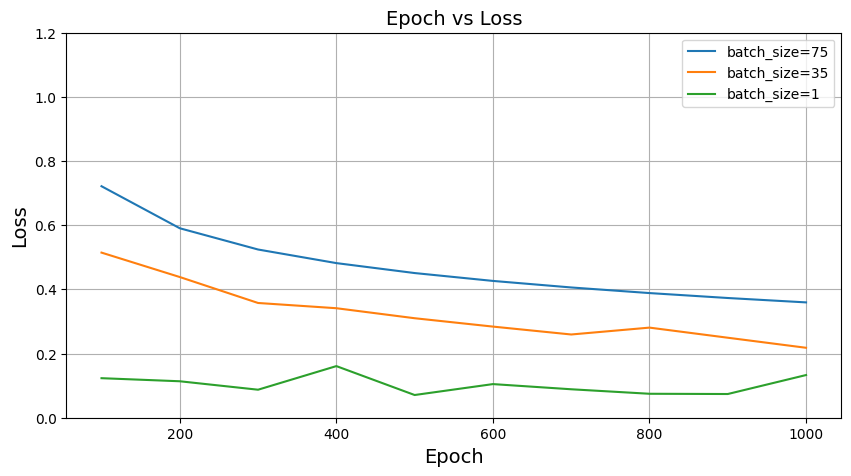

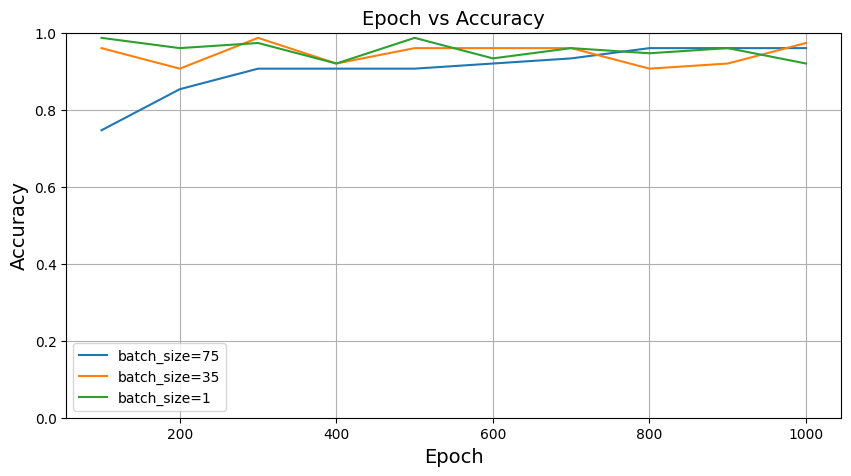

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D

# 載入 iris 數據集
iris = load_iris()
x_org, y_org = iris.data, iris.target

# 提取萼片長度（0）和花瓣長度（2）
x_select = x_org

# 新增虛擬變數
x_all = np.insert(x_select, 0, 1.0, axis=1)

# 將 y 轉換為 One-hot 向量
ohe = OneHotEncoder(sparse_output=False, categories='auto')
y_work = np.c_[y_org]
y_all_one = ohe.fit_transform(y_work)

# 分割數據集
x_train, x_test, y_train, y_test, y_train_one, y_test_one = train_test_split(
    x_all, y_org, y_all_one, train_size=75, test_size=75, random_state=123)

# softmax 函式
def softmax(x):
    x = x.T
    x_max = x.max(axis=0)
    x = x - x_max
    w = np.exp(x)
    return (w / w.sum(axis=0)).T

# 預測函式
def pred(x, W):
    return softmax(x @ W)

# 交叉熵損失函式
def cross_entropy(yt, yp):
    return -np.mean(np.sum(yt * np.log(yp + 1e-10), axis=1))

# 計算測試集損失
def compute_loss(X, y_one, W):
    yp = pred(X, W)
    return cross_entropy(y_one, yp)

# 計算測試集準確率
def compute_accuracy(X, y, W):
    yp_one = pred(X, W)
    yp = np.argmax(yp_one, axis=1)
    return accuracy_score(y, yp)

# 訓練函式（使用有限差分法計算梯度）
def training(nb_epochs, batch_size, alpha, W):
    M = len(x_train)
    history = []
    epsilon = 1e-6

    for epoch in range(nb_epochs):
        # 打亂訓練資料
        indices = np.random.permutation(M)
        x_train_shuffled = x_train[indices]
        y_train_shuffled = y_train_one[indices]

        # 批次處理
        for start_idx in range(0, M, batch_size):
            end_idx = min(start_idx + batch_size, M)
            X_batch = x_train_shuffled[start_idx:end_idx]
            y_batch = y_train_shuffled[start_idx:end_idx]

            # 使用有限差分法計算梯度
            gradient = np.zeros_like(W)
            for i in range(W.shape[0]):
                for j in range(W.shape[1]):
                    W_plus = W.copy()
                    W_plus[i, j] += epsilon
                    loss_plus = cross_entropy(y_batch, pred(X_batch, W_plus))

                    W_minus = W.copy()
                    W_minus[i, j] -= epsilon
                    loss_minus = cross_entropy(y_batch, pred(X_batch, W_minus))

                    gradient[i, j] = (loss_plus - loss_minus) / (2 * epsilon)

            W -= alpha * gradient

        if (epoch + 1) % 100 == 0:
            test_loss = compute_loss(x_test, y_test_one, W)
            test_accuracy = compute_accuracy(x_test, y_test, W)
            history.append((epoch + 1, test_loss, test_accuracy))
            print(f"Epoch {epoch + 1}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_accuracy:.4f}")

    return W, np.array(history)

# 初始化權重
D = x_train.shape[1]
N = y_train_one.shape[1]
W_init = np.linspace(0.5, 1.5, D * N).reshape(D, N)

print("Training with batch_size = 75")
W1, history1 = training(1000, 75, 0.01, W_init.copy())
print("\nTraining with batch_size = 35")
W2, history2 = training(1000, 35, 0.01, W_init.copy())
print("\nTraining with batch_size = 1")
W3, history3 = training(1000, 1, 0.01, W_init.copy())

print("\nResults for batch_size = 75:")
print(f"初始狀態: 損失函數: {history1[0, 1]:.4f}, 精度: {history1[0, 2]:.4f}")
print(f"最終狀態: 損失函數: {history1[-1, 1]:.4f}, 精度: {history1[-1, 2]:.4f}")
print("\nResults for batch_size = 35:")
print(f"初始狀態: 損失函數: {history2[0, 1]:.4f}, 精度: {history2[0, 2]:.4f}")
print(f"最終狀態: 損失函數: {history2[-1, 1]:.4f}, 精度: {history2[-1, 2]:.4f}")
print("\nResults for batch_size = 1:")
print(f"初始狀態: 損失函數: {history3[0, 1]:.4f}, 精度: {history3[0, 2]:.4f}")
print(f"最終狀態: 損失函數: {history3[-1, 1]:.4f}, 精度: {history3[-1, 2]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(history1[:, 0], history1[:, 1], label='batch_size=75')
plt.plot(history2[:, 0], history2[:, 1], label='batch_size=35')
plt.plot(history3[:, 0], history3[:, 1], label='batch_size=1')
plt.grid()
plt.ylim(0, 1.2)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.title('Epoch vs Loss', fontsize=14)
plt.legend()
plt.savefig('loss_comparison.png')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history1[:, 0], history1[:, 2], label='batch_size=75')
plt.plot(history2[:, 0], history2[:, 2], label='batch_size=35')
plt.plot(history3[:, 0], history3[:, 2], label='batch_size=1')
plt.ylim(0, 1)
plt.grid()
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.title('Epoch vs Accuracy', fontsize=14)
plt.legend()
plt.savefig('accuracy_comparison.png')
plt.show()